In [42]:
import pandas as pd
import matplotlib.pyplot as plt
data={
    "YEAR": [],
    "MONTH_NUM": [],
    "MONTH_MON": [],
    "FLT_DATE": [],
    "APT_ICAO": [],
    "APT_NAME": [],
    "STATE_NAME": [],
    "FLT_DEP_1": [],
    "FLT_ARR_1": [],
    "FLT_TOT_1": [],
    "FLT_DEP_IFR_2": [],
    "FLT_ARR_IFR_2": [],
    "FLT_TOT_IFR_2": []
}
df=pd.read_csv("/content/airport_traffic_2025[1].csv")
print(df.head())

   YEAR  MONTH_NUM MONTH_MON    FLT_DATE APT_ICAO    APT_NAME STATE_NAME  \
0  2025          1       JAN  2025-01-01     LATI      Tirana    Albania   
1  2025          1       JAN  2025-01-01     UDYZ     Yerevan    Armenia   
2  2025          1       JAN  2025-01-01     LOWG        Graz    Austria   
3  2025          1       JAN  2025-01-01     LOWI   Innsbruck    Austria   
4  2025          1       JAN  2025-01-01     LOWK  Klagenfurt    Austria   

   FLT_DEP_1  FLT_ARR_1  FLT_TOT_1  FLT_DEP_IFR_2  FLT_ARR_IFR_2  \
0         64         62        126            NaN            NaN   
1         57         54        111            NaN            NaN   
2          7          6         13            NaN            NaN   
3         24         25         49            NaN            NaN   
4          2          0          2            NaN            NaN   

   FLT_TOT_IFR_2  
0            NaN  
1            NaN  
2            NaN  
3            NaN  
4            NaN  


In [43]:
print(df.isna().sum())
df["FLT_DEP_IFR_2"]=df["FLT_DEP_IFR_2"].fillna(0)
df["FLT_ARR_IFR_2"]=df["FLT_ARR_IFR_2"].fillna(0)
df["FLT_TOT_IFR_2"]=df["FLT_TOT_IFR_2"].fillna(0)
print(df.head())

YEAR                 0
MONTH_NUM            0
MONTH_MON            0
FLT_DATE             0
APT_ICAO             0
APT_NAME             0
STATE_NAME           0
FLT_DEP_1            0
FLT_ARR_1            0
FLT_TOT_1            0
FLT_DEP_IFR_2    81892
FLT_ARR_IFR_2    81892
FLT_TOT_IFR_2    81892
dtype: int64
   YEAR  MONTH_NUM MONTH_MON    FLT_DATE APT_ICAO    APT_NAME STATE_NAME  \
0  2025          1       JAN  2025-01-01     LATI      Tirana    Albania   
1  2025          1       JAN  2025-01-01     UDYZ     Yerevan    Armenia   
2  2025          1       JAN  2025-01-01     LOWG        Graz    Austria   
3  2025          1       JAN  2025-01-01     LOWI   Innsbruck    Austria   
4  2025          1       JAN  2025-01-01     LOWK  Klagenfurt    Austria   

   FLT_DEP_1  FLT_ARR_1  FLT_TOT_1  FLT_DEP_IFR_2  FLT_ARR_IFR_2  \
0         64         62        126            0.0            0.0   
1         57         54        111            0.0            0.0   
2          7          6    

In [44]:
df["FLT_DATE"]=pd.to_datetime(df["FLT_DATE"])

In [45]:
df['total_attendu'] = df['FLT_DEP_1'] + df['FLT_ARR_1']
df['anomalie'] = df['FLT_TOT_1'] != df['total_attendu']
df.loc[df['anomalie'], 'FLT_TOT_1'] = df['total_attendu']
print(df.head())

   YEAR  MONTH_NUM MONTH_MON   FLT_DATE APT_ICAO    APT_NAME STATE_NAME  \
0  2025          1       JAN 2025-01-01     LATI      Tirana    Albania   
1  2025          1       JAN 2025-01-01     UDYZ     Yerevan    Armenia   
2  2025          1       JAN 2025-01-01     LOWG        Graz    Austria   
3  2025          1       JAN 2025-01-01     LOWI   Innsbruck    Austria   
4  2025          1       JAN 2025-01-01     LOWK  Klagenfurt    Austria   

   FLT_DEP_1  FLT_ARR_1  FLT_TOT_1  FLT_DEP_IFR_2  FLT_ARR_IFR_2  \
0         64         62        126            0.0            0.0   
1         57         54        111            0.0            0.0   
2          7          6         13            0.0            0.0   
3         24         25         49            0.0            0.0   
4          2          0          2            0.0            0.0   

   FLT_TOT_IFR_2  total_attendu  anomalie  
0            0.0            126     False  
1            0.0            111     False  
2       

In [46]:
df['trafic_VFR'] = df['FLT_TOT_1'] - df['FLT_TOT_IFR_2']
df.loc[df['trafic_VFR'] < 0, 'trafic_VFR'] = 0
print(df.head())

   YEAR  MONTH_NUM MONTH_MON   FLT_DATE APT_ICAO    APT_NAME STATE_NAME  \
0  2025          1       JAN 2025-01-01     LATI      Tirana    Albania   
1  2025          1       JAN 2025-01-01     UDYZ     Yerevan    Armenia   
2  2025          1       JAN 2025-01-01     LOWG        Graz    Austria   
3  2025          1       JAN 2025-01-01     LOWI   Innsbruck    Austria   
4  2025          1       JAN 2025-01-01     LOWK  Klagenfurt    Austria   

   FLT_DEP_1  FLT_ARR_1  FLT_TOT_1  FLT_DEP_IFR_2  FLT_ARR_IFR_2  \
0         64         62        126            0.0            0.0   
1         57         54        111            0.0            0.0   
2          7          6         13            0.0            0.0   
3         24         25         49            0.0            0.0   
4          2          0          2            0.0            0.0   

   FLT_TOT_IFR_2  total_attendu  anomalie  trafic_VFR  
0            0.0            126     False       126.0  
1            0.0            

In [47]:
df['ratio_IFR'] = (df['FLT_TOT_IFR_2'] / df['FLT_TOT_1']) * 100
print(df.head())

   YEAR  MONTH_NUM MONTH_MON   FLT_DATE APT_ICAO    APT_NAME STATE_NAME  \
0  2025          1       JAN 2025-01-01     LATI      Tirana    Albania   
1  2025          1       JAN 2025-01-01     UDYZ     Yerevan    Armenia   
2  2025          1       JAN 2025-01-01     LOWG        Graz    Austria   
3  2025          1       JAN 2025-01-01     LOWI   Innsbruck    Austria   
4  2025          1       JAN 2025-01-01     LOWK  Klagenfurt    Austria   

   FLT_DEP_1  FLT_ARR_1  FLT_TOT_1  FLT_DEP_IFR_2  FLT_ARR_IFR_2  \
0         64         62        126            0.0            0.0   
1         57         54        111            0.0            0.0   
2          7          6         13            0.0            0.0   
3         24         25         49            0.0            0.0   
4          2          0          2            0.0            0.0   

   FLT_TOT_IFR_2  total_attendu  anomalie  trafic_VFR  ratio_IFR  
0            0.0            126     False       126.0        0.0  
1     

In [48]:
df['jour_semaine'] = df['FLT_DATE'].dt.day_name()
df['num_semaine'] = df['FLT_DATE'].dt.isocalendar().week
print(df.head())

   YEAR  MONTH_NUM MONTH_MON   FLT_DATE APT_ICAO    APT_NAME STATE_NAME  \
0  2025          1       JAN 2025-01-01     LATI      Tirana    Albania   
1  2025          1       JAN 2025-01-01     UDYZ     Yerevan    Armenia   
2  2025          1       JAN 2025-01-01     LOWG        Graz    Austria   
3  2025          1       JAN 2025-01-01     LOWI   Innsbruck    Austria   
4  2025          1       JAN 2025-01-01     LOWK  Klagenfurt    Austria   

   FLT_DEP_1  FLT_ARR_1  FLT_TOT_1  FLT_DEP_IFR_2  FLT_ARR_IFR_2  \
0         64         62        126            0.0            0.0   
1         57         54        111            0.0            0.0   
2          7          6         13            0.0            0.0   
3         24         25         49            0.0            0.0   
4          2          0          2            0.0            0.0   

   FLT_TOT_IFR_2  total_attendu  anomalie  trafic_VFR  ratio_IFR jour_semaine  \
0            0.0            126     False       126.0      

In [49]:
def segmenter(vols):
    if vols < 1000:
        return "Petit"
    elif vols < 1200:
        return "Moyen"
    else:
        return "Hub International"
df['segment'] = df['FLT_TOT_1'].apply(segmenter)
print(df.head())

   YEAR  MONTH_NUM MONTH_MON   FLT_DATE APT_ICAO    APT_NAME STATE_NAME  \
0  2025          1       JAN 2025-01-01     LATI      Tirana    Albania   
1  2025          1       JAN 2025-01-01     UDYZ     Yerevan    Armenia   
2  2025          1       JAN 2025-01-01     LOWG        Graz    Austria   
3  2025          1       JAN 2025-01-01     LOWI   Innsbruck    Austria   
4  2025          1       JAN 2025-01-01     LOWK  Klagenfurt    Austria   

   FLT_DEP_1  FLT_ARR_1  FLT_TOT_1  FLT_DEP_IFR_2  FLT_ARR_IFR_2  \
0         64         62        126            0.0            0.0   
1         57         54        111            0.0            0.0   
2          7          6         13            0.0            0.0   
3         24         25         49            0.0            0.0   
4          2          0          2            0.0            0.0   

   FLT_TOT_IFR_2  total_attendu  anomalie  trafic_VFR  ratio_IFR jour_semaine  \
0            0.0            126     False       126.0      

In [50]:
top10_hubs = df.groupby("APT_NAME")["FLT_TOT_1"].sum().nlargest(10)
print("Top 10 hubs par trafic total :")
print(top10_hubs)

Top 10 hubs par trafic total :
APT_NAME
Istanbul                     544121
Amsterdam - Schiphol         493042
London - Heathrow            480072
Paris - Charles-de-Gaulle    479761
Frankfurt                    460295
Madrid - Barajas             430785
Barcelona                    360831
Munich                       334833
Rome - Fiumicino             322766
Athens                       278241
Name: FLT_TOT_1, dtype: int64


In [51]:
top_countries = df.groupby("STATE_NAME")["FLT_TOT_1"].sum().sort_values(ascending=False)
print("\nPays les plus actifs en volume de vols :")
print(top_countries)


Pays les plus actifs en volume de vols :
STATE_NAME
Spain                          2361488
United Kingdom                 2002205
France                         1741728
Germany                        1704444
Italy                          1358471
Türkiye                        1232639
Norway                          681781
Greece                          615086
Netherlands                     539022
Poland                          515683
Portugal                        499512
Switzerland                     447720
Austria                         324530
Belgium                         322128
Ireland                         321603
Sweden                          261313
Denmark                         256659
Morocco                         246302
Czech Republic                  160004
Finland                         156035
Israel                          140706
Hungary                         138208
Romania                         136397
Cyprus                          102198
Serbia     

In [52]:
df['ratio_arr_dep'] = df['FLT_ARR_1'] / df['FLT_DEP_1']
print("Ratio Arrivées/Départs par aéroport :")
print(df[['APT_ICAO', 'ratio_arr_dep']])

Ratio Arrivées/Départs par aéroport :
       APT_ICAO  ratio_arr_dep
0          LATI       0.968750
1          UDYZ       0.947368
2          LOWG       0.857143
3          LOWI       1.041667
4          LOWK       0.000000
...         ...            ...
116015     EGNX       1.134615
116016     EGPD       0.942857
116017     EGPF       1.013889
116018     EGPH       1.000000
116019     EGSS       1.000000

[116020 rows x 2 columns]


In [53]:
top5_hotspots = df.groupby("APT_ICAO")["FLT_TOT_IFR_2"].sum().nlargest(5)
print("\nTop 5 hotspots IFR :")
print(top5_hotspots)


Top 5 hotspots IFR :
APT_ICAO
LTFM    548073.0
EHAM    492546.0
EGLL    479042.0
LFPG    478705.0
EDDF    460143.0
Name: FLT_TOT_IFR_2, dtype: float64


In [54]:
df['month'] = df['FLT_DATE'].dt.month
monthly_growth = df.groupby('month')["FLT_TOT_IFR_2"].sum().pct_change().fillna(0)
print("\nCroissance mensuelle du trafic IFR :")
print(monthly_growth)


Croissance mensuelle du trafic IFR :
month
1     0.000000
2    -0.033029
3     0.163172
4     0.097644
5     0.065002
6     0.013884
7     0.047885
8    -0.000238
9    -0.047059
10   -0.007308
11   -0.180433
12    0.017607
Name: FLT_TOT_IFR_2, dtype: float64


In [55]:
jour_record = df.loc[df['FLT_TOT_1'].idxmax(), ['FLT_DATE', 'FLT_TOT_1']]
print("Jour record de 2025:\n", jour_record)

Jour record de 2025:
 FLT_DATE     2025-07-20 00:00:00
FLT_TOT_1                   1688
Name: 63675, dtype: object


In [56]:
df['month'] = df['FLT_DATE'].dt.month
monthly_growth = df.groupby('month')["FLT_TOT_1"].sum().pct_change().fillna(0)
mois_max_growth = monthly_growth.idxmax()
print("Mois de plus forte croissance :", mois_max_growth)

Mois de plus forte croissance : 3


In [57]:
top_country = df.groupby("STATE_NAME")["FLT_TOT_1"].sum().idxmax()
print("Réseau national le plus dynamique :", top_country)

Réseau national le plus dynamique : Spain


In [58]:
stability = df.groupby("APT_ICAO")["FLT_TOT_1"].std()
stable_airport = stability.idxmin()
print("Aéroport le plus stable :", stable_airport)

Aéroport le plus stable : GCGM


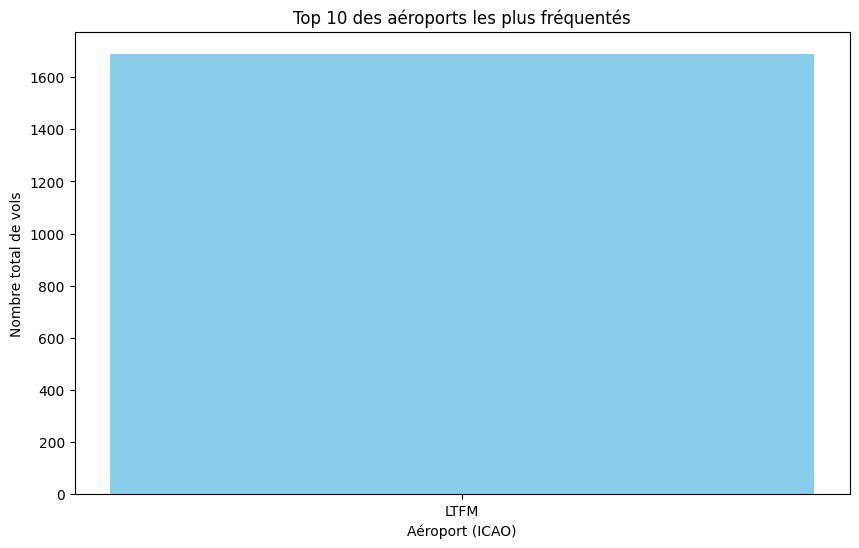

In [59]:
top10 = df.nlargest(10, "FLT_TOT_1")
plt.figure(figsize=(10,6))
plt.bar(top10["APT_ICAO"], top10["FLT_TOT_1"], color="skyblue")
plt.title("Top 10 des aéroports les plus fréquentés")
plt.xlabel("Aéroport (ICAO)")
plt.ylabel("Nombre total de vols")
plt.show()

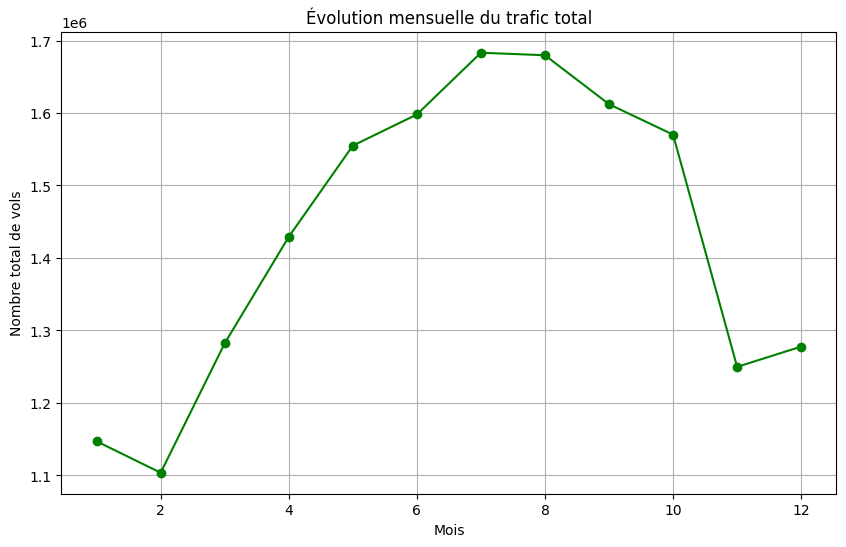

In [60]:
monthly_totals = df.groupby("month")["FLT_TOT_1"].sum()
plt.figure(figsize=(10,6))
plt.plot(monthly_totals.index, monthly_totals.values, marker="o", linestyle="-", color="green")
plt.title("Évolution mensuelle du trafic total")
plt.xlabel("Mois")
plt.ylabel("Nombre total de vols")
plt.grid(True)
plt.show()

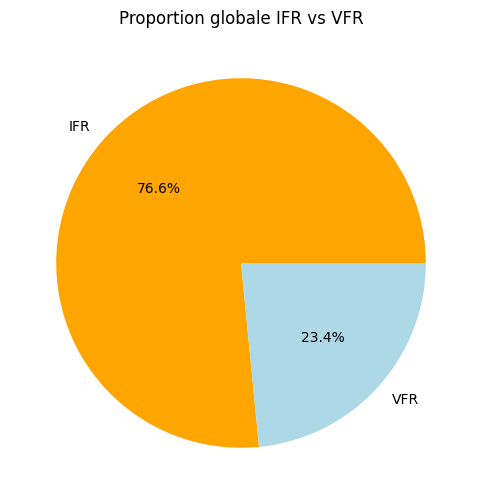

In [61]:
total_IFR = df["FLT_TOT_IFR_2"].sum()
total_VFR = df["FLT_TOT_1"].sum() - total_IFR
plt.figure(figsize=(6,6))
plt.pie([total_IFR, total_VFR], labels=["IFR", "VFR"], autopct="%1.1f%%", colors=["orange","lightblue"])
plt.title("Proportion globale IFR vs VFR")
plt.show()